# Handwritten OCR Fine-tuning Notebook (Janus-Pro-1B)

This notebook is built for **Google Colab GPU** and fine-tunes `deepseek-ai/Janus-Pro-1B` for handwritten text understanding.

## Dataset understanding (your format)
- `transcriptions.csv` has one row per page image: `image_path, transcription`.
- Each `transcription` usually contains:
  1. Header (`Sentence Database`, sample id)
  2. Printed reference paragraph
  3. Handwritten paragraph (noisy OCR)
  4. `Name:` line
- For training, we use a practical strategy:
  - **Input image**: handwritten-focused crop from lower page area
  - **Target text**: cleaner printed reference extracted from transcription prefix

> This is weak supervision but typically improves handwritten recognition quality versus raw OCR-only training.

In [2]:
# Colab setup (run once)
%pip -q install -U transformers==4.46.3 datasets accelerate peft bitsandbytes sentencepiece Pillow==9.5.0 opencv-python-headless evaluate jiwer


In [3]:
import os
import re
import gc
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset

from datasets import Dataset as HFDataset

from transformers import (
    AutoConfig,
    AutoProcessor,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))


CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.64


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# -------- Config --------
@dataclass
class CFG:
    model_name: str = 'deepseek-ai/Janus-Pro-1B'
    csv_path: str = '/content/transcriptions.csv'
    image_root: str = '/content/drive/MyDrive/data'
    # Updated to save everything to Drive for persistence
    work_dir: str = '/content/drive/MyDrive/brainink_janus_hw'

    # data
    min_target_chars: int = 20
    max_target_chars: int = 1200
    max_samples: int | None = None      # set e.g. 500 for fast debug
    val_ratio: float = 0.1

    # handwritten crop (bottom area of IAM-like forms)
    crop_top_ratio: float = 0.21
    crop_bottom_ratio: float = 0.94

    # training
    num_train_epochs: int = 2
    per_device_train_batch_size: int = 1
    per_device_eval_batch_size: int = 1
    gradient_accumulation_steps: int = 8
    learning_rate: float = 2e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.03
    max_length: int = 1024

    # lora
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05

cfg = CFG()

os.makedirs(cfg.work_dir, exist_ok=True)
os.makedirs(Path(cfg.work_dir) / 'crops', exist_ok=True)

print('Model:', cfg.model_name)
print('CSV:', cfg.csv_path)
print('Image root:', cfg.image_root)
print('Work dir:', cfg.work_dir)

PROMPT = 'Read the handwritten text in this image and transcribe it exactly.'

Model: deepseek-ai/Janus-Pro-1B
CSV: /content/transcriptions.csv
Image root: /content/drive/MyDrive/data
Work dir: /content/drive/MyDrive/brainink_janus_hw


In [6]:
# -------- Load processor + base model (4-bit QLoRA-ready) --------
# Optional if model is gated/private:
# from huggingface_hub import login
# login(token='YOUR_HF_TOKEN')

import importlib
import subprocess
import sys

# Janus registers its custom `multi_modality` architecture at import time.
# If missing, install it and then import.
try:
    import janus
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/deepseek-ai/Janus.git'])

import janus  # noqa: F401
from janus.models import VLChatProcessor  # ensures model/config registration

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

cfg_obj = AutoConfig.from_pretrained(cfg.model_name, trust_remote_code=True)
print('HF config model_type:', getattr(cfg_obj, 'model_type', 'unknown'))

# Keep a HF-compatible processor variable used by later cells.
# AutoProcessor is preferred for the collator/generation flow in this notebook.
try:
    processor = AutoProcessor.from_pretrained(cfg.model_name, trust_remote_code=True)
except Exception:
    processor = VLChatProcessor.from_pretrained(cfg.model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    quantization_config=bnb_config if torch.cuda.is_available() else None,
    device_map='auto',
    trust_remote_code=True,
)

print('Processor loaded:', type(processor).__name__)
print('Model loaded:', type(base_model).__name__)

Python version is above 3.10, patching the collections module.


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:520: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

HF config model_type: multi_modality


processor_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/344 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.


pytorch_model.bin:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Processor loaded: LlamaTokenizerFast
Model loaded: MultiModalityCausalLM


In [7]:
import transformers
print(transformers.__version__)

4.46.3


In [8]:
# -------- TOP QUICK TEST CELL (before fine-tuning) --------
# This confirms your model + processor + data paths work.

df_test = pd.read_csv(cfg.csv_path)
sample_rel = df_test.iloc[0]['image_path']
sample_abs = Path(cfg.image_root) / sample_rel

img = Image.open(sample_abs).convert('RGB')
w, h = img.size
y0 = int(h * cfg.crop_top_ratio)
y1 = int(h * cfg.crop_bottom_ratio)
img_hw = img.crop((0, y0, w, y1))

# First try generic HF multimodal processor flow; if it fails, fallback to Janus-native flow.
decoded = None
try:
    tokenizer_obj = getattr(processor, 'tokenizer', None)
    has_template = bool(getattr(tokenizer_obj, 'chat_template', None))

    if hasattr(processor, 'apply_chat_template') and has_template:
        messages = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': PROMPT},
                ],
            }
        ]
        prompt_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    else:
        prompt_text = f'<image>\n{PROMPT}\nAssistant:'

    inputs = processor(images=[img_hw], text=[prompt_text], return_tensors='pt')
    inputs = {k: v.to(base_model.device) if hasattr(v, 'to') else v for k, v in inputs.items()}

    with torch.no_grad():
        out = base_model.generate(**inputs, max_new_tokens=180, do_sample=False)

    decoded = processor.batch_decode(out, skip_special_tokens=True)[0]
except Exception as generic_err:
    print('Generic processor path failed, switching to Janus-native path:')
    print(repr(generic_err))

    from janus.models import VLChatProcessor
    vl_processor = VLChatProcessor.from_pretrained(cfg.model_name)

    conversation = [
        {
            'role': 'User',
            'content': '<image_placeholder>\n' + PROMPT,
            'images': [str(sample_abs)],
        },
        {'role': 'Assistant', 'content': ''},
    ]

    # Janus expects PIL images list in the same order as image placeholders.
    pil_images = [img_hw]
    prepare_inputs = vl_processor(
        conversations=conversation,
        images=pil_images,
        force_batchify=True,
    ).to(base_model.device)

    # Fix dtype mismatch in Janus vision tower (e.g., bf16 inputs vs fp16 weights/bias).
    if hasattr(prepare_inputs, 'pixel_values') and prepare_inputs.pixel_values is not None:
        try:
            vision_dtype = next(base_model.vision_model.parameters()).dtype
        except Exception:
            vision_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        prepare_inputs.pixel_values = prepare_inputs.pixel_values.to(device=base_model.device, dtype=vision_dtype)

    with torch.no_grad():
        inputs_embeds = base_model.prepare_inputs_embeds(**prepare_inputs)
        outputs = base_model.language_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=prepare_inputs.attention_mask,
            pad_token_id=vl_processor.tokenizer.eos_token_id,
            bos_token_id=vl_processor.tokenizer.bos_token_id,
            eos_token_id=vl_processor.tokenizer.eos_token_id,
            max_new_tokens=180,
            do_sample=False,
            use_cache=True,
        )

    decoded = vl_processor.tokenizer.decode(outputs[0].cpu().tolist(), skip_special_tokens=True)

print('Sample image:', sample_rel)
print('--- RAW MODEL OUTPUT ---')
print(decoded)

Generic processor path failed, switching to Janus-native path:
TypeError("PreTrainedTokenizerFast._batch_encode_plus() got an unexpected keyword argument 'images'")


preprocessor_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

Some kwargs in processor config are unused and will not have any effect: image_tag, add_special_token, mask_prompt, num_image_tokens, sft_format, ignore_id. 


Sample image: 000/a01-000u.png
--- RAW MODEL OUTPUT ---
 I move to stop Mr. Gaitskell from nominating any more Labour Party to be made at a meeting of Labour MPs tomorrow.


In [9]:
# -------- Parse transcription into cleaner supervised target --------
def normalize_space(text: str) -> str:
    text = text.replace('\r', '\n')
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def extract_printed_target(raw: str) -> str:
    if not isinstance(raw, str):
        return ''

    text = normalize_space(raw)
    lines = [ln.strip() for ln in text.split('\n') if ln.strip()]
    if not lines:
        return ''

    # remove common header lines
    if lines and lines[0].lower().startswith('sentence database'):
        lines = lines[1:]
    if lines and re.match(r'^[A-Za-z]\d{2}-\d{3}', lines[0]):
        lines = lines[1:]

    # truncate before Name
    cut = []
    for ln in lines:
        if ln.lower().startswith('name'):
            break
        cut.append(ln)
    lines = cut
    if not lines:
        return ''

    # Heuristic: printed text prefix has longer lines; keep prefix until sustained short lines
    printed = []
    short_streak = 0
    for ln in lines:
        printed.append(ln)
        if len(ln) < 35:
            short_streak += 1
        else:
            short_streak = 0

        if len(printed) >= 3 and short_streak >= 2:
            printed = printed[:-2]
            break

    if not printed:
        printed = lines[:6]

    label = ' '.join(printed)
    label = re.sub(r'\s+', ' ', label).strip()
    return label


df = pd.read_csv(cfg.csv_path)
df['image_path'] = df['image_path'].astype(str).str.strip()
df['target_text'] = df['transcription'].apply(extract_printed_target)

# basic filtering
df = df[df['target_text'].str.len() >= cfg.min_target_chars].copy()
df = df[df['target_text'].str.len() <= cfg.max_target_chars].copy()

# ensure files exist
df['abs_image_path'] = df['image_path'].apply(lambda p: str((Path(cfg.image_root) / p).resolve()))
df = df[df['abs_image_path'].apply(lambda p: Path(p).exists())].copy()

if cfg.max_samples is not None:
    df = df.sample(n=min(cfg.max_samples, len(df)), random_state=SEED).reset_index(drop=True)

df = df.reset_index(drop=True)
print('Usable rows:', len(df))
display(df[['image_path', 'target_text']].head(5))

Usable rows: 1520


,image_path,target_text
0,000/a01-000u.png,A MOVE to stop Mr. Gaitskell from nominating a...
1,000/a01-003u.png,"Though they may gather some Left-wing support,..."
2,000/a01-007u.png,"Since 1958, 13 Labour life Peers and Peeresses..."
3,000/a01-011u.png,Delegates from Mr. Kenneth Kaunda's United Nat...
4,000/a01-014u.png,Sir Roy's United Federal Party is boycotting t...


In [10]:
# -------- Build handwritten-focused crops --------
crop_dir = Path(cfg.work_dir) / 'crops'
crop_dir.mkdir(parents=True, exist_ok=True)

def make_crop(abs_image_path: str, rel_image_path: str) -> str:
    out_path = crop_dir / rel_image_path

    # Check if file already exists in Drive to skip recreation
    if out_path.exists():
        return str(out_path)

    # If not, process and save
    out_path.parent.mkdir(parents=True, exist_ok=True)

    img = Image.open(abs_image_path).convert('RGB')
    w, h = img.size
    y0 = max(0, int(h * cfg.crop_top_ratio))
    y1 = min(h, int(h * cfg.crop_bottom_ratio))
    if y1 <= y0:
        y0, y1 = int(h * 0.21), h

    crop = img.crop((0, y0, w, y1))
    crop.save(out_path)
    return str(out_path)

print('Checking for existing crops...')
df['crop_path'] = [make_crop(a, r) for a, r in zip(df['abs_image_path'], df['image_path'])]
print('Crops ready (skipped existing):', len(df))
display(df[['image_path', 'crop_path', 'target_text']].head(3))

Checking for existing crops...
Crops ready (skipped existing): 1520


,image_path,crop_path,target_text
0,000/a01-000u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,A MOVE to stop Mr. Gaitskell from nominating a...
1,000/a01-003u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Though they may gather some Left-wing support,..."
2,000/a01-007u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Since 1958, 13 Labour life Peers and Peeresses..."


In [11]:
# -------- Train/val split --------
idx = np.arange(len(df))
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

val_size = max(1, int(len(df) * cfg.val_ratio))
val_idx = idx[:val_size]
train_idx = idx[val_size:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print('Train size:', len(train_df))
print('Val size:', len(val_df))

train_hf = HFDataset.from_pandas(train_df[['crop_path', 'target_text']], preserve_index=False)
val_hf = HFDataset.from_pandas(val_df[['crop_path', 'target_text']], preserve_index=False)

Train size: 1368
Val size: 152


In [12]:
# -------- Prepare model for LoRA fine-tuning --------
from peft import PeftModel

lm_for_lora = base_model.language_model

# Check if already wrapped to prevent double-wrapping on cell re-run
if isinstance(lm_for_lora, PeftModel):
    print('Language model is already a PEFT model. Skipping LoRA injection.')
else:
    if getattr(lm_for_lora, 'supports_gradient_checkpointing', False):
        lm_for_lora.gradient_checkpointing_enable()
        print('Gradient checkpointing (language_model): enabled')
    else:
        print('Gradient checkpointing (language_model): not supported, skipping')

    # Prepare only language model for k-bit training (safer with PEFT + Trainer).
    try:
        lm_for_lora = prepare_model_for_kbit_training(lm_for_lora, use_gradient_checkpointing=False)
        print('prepare_model_for_kbit_training: applied to language_model')
    except NotImplementedError as err:
        print('prepare_model_for_kbit_training skipped due to model API limitation:')
        print(repr(err))
        print('Continuing with language_model as-is for LoRA injection.')

    # Detect LoRA target modules in the language model only.
    preferred_targets = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
    available_targets = sorted({
        name.split('.')[-1]
        for name, module in lm_for_lora.named_modules()
        if hasattr(module, 'weight') and name.split('.')[-1] in preferred_targets
    })

    if not available_targets:
        raise RuntimeError(
            'No LoRA target modules found in language_model. '
            'Inspect language_model.named_modules() and adjust target module names.'
        )

    print('LoRA targets:', available_targets)

    lora_cfg = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=available_targets,
    )

    peft_lm = get_peft_model(lm_for_lora, lora_cfg)
    peft_lm.print_trainable_parameters()

    # Put PEFT-wrapped language model back into Janus multimodal model.
    base_model.language_model = peft_lm

class JanusTrainerWrapper(torch.nn.Module):
    def __init__(self, mm_model):
        super().__init__()
        self.mm_model = mm_model
        # Fix: Do not register self.language_model as a submodule to avoid "shared memory" errors
        # in safetensors saving (duplicate state_dict keys).
        # We will access it via property.

    @property
    def language_model(self):
        return self.mm_model.language_model

    @property
    def config(self):
        return self.mm_model.config

    @property
    def device(self):
        return next(self.mm_model.parameters()).device

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        pixel_values=None,
        images_seq_mask=None,
        images_emb_mask=None,
        labels=None,
        **kwargs,
    ):
        if pixel_values is not None and images_seq_mask is not None and images_emb_mask is not None:
            if input_ids is not None:
                input_ids = input_ids.to(self.device)
            if attention_mask is not None:
                attention_mask = attention_mask.to(self.device)
            if labels is not None:
                labels = labels.to(self.device)

            try:
                vision_dtype = next(self.mm_model.vision_model.parameters()).dtype
                pixel_values = pixel_values.to(device=self.device, dtype=vision_dtype)
            except Exception:
                pixel_values = pixel_values.to(self.device)

            prepared = {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'pixel_values': pixel_values,
                'images_seq_mask': images_seq_mask.to(self.device),
                'images_emb_mask': images_emb_mask.to(self.device),
            }

            # Janus uses in-place replacement inside prepare_inputs_embeds;
            # run that preparation without autograd to avoid leaf in-place errors.
            with torch.no_grad():
                inputs_embeds = self.mm_model.prepare_inputs_embeds(**prepared)

            return self.language_model(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                labels=labels,
                return_dict=True,
            )

        return self.language_model(
            input_ids=input_ids.to(self.device) if input_ids is not None else None,
            attention_mask=attention_mask.to(self.device) if attention_mask is not None else None,
            labels=labels.to(self.device) if labels is not None else None,
            return_dict=True,
        )

model = JanusTrainerWrapper(base_model)
print('Trainer model:', type(model).__name__)

Gradient checkpointing (language_model): enabled
prepare_model_for_kbit_training: applied to language_model
LoRA targets: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']
trainable params: 15,138,816 || all params: 1,667,794,944 || trainable%: 0.9077
Trainer model: JanusTrainerWrapper


In [13]:
# -------- Data collator for image-text causal LM training --------
from janus.models import VLChatProcessor

def format_training_text(answer_text: str):
    tokenizer_obj = getattr(processor, 'tokenizer', None)
    has_template = bool(getattr(tokenizer_obj, 'chat_template', None))

    if hasattr(processor, 'apply_chat_template') and has_template:
        msgs = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': PROMPT},
                ],
            },
            {
                'role': 'assistant',
                'content': [
                    {'type': 'text', 'text': answer_text},
                ],
            },
        ]
        try:
            return processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        except Exception:
            pass

    return f'<image>\n{PROMPT}\nAssistant: {answer_text}'


def _processor_supports_images_arg(proc):
    try:
        _ = proc(images=[Image.new('RGB', (16, 16))], text=['test'], return_tensors='pt')
        return True
    except TypeError as err:
        if 'unexpected keyword argument' in str(err) and 'images' in str(err):
            return False
        return False
    except Exception:
        return True


PROCESSOR_SUPPORTS_IMAGES = _processor_supports_images_arg(processor)
print('Processor supports images arg:', PROCESSOR_SUPPORTS_IMAGES)

# Cache Janus processor for tokenizer-only processor environments.
vl_processor = None
if not PROCESSOR_SUPPORTS_IMAGES:
    vl_processor = VLChatProcessor.from_pretrained(cfg.model_name)


def collate_fn(batch):
    # Notebook uses batch_size=1, so keep this path simple and robust.
    sample = batch[0]
    image = Image.open(sample['crop_path']).convert('RGB')
    answer_text = sample['target_text']

    if PROCESSOR_SUPPORTS_IMAGES:
        texts = [format_training_text(answer_text)]
        enc = processor(
            images=[image],
            text=texts,
            padding=True,
            truncation=True,
            max_length=cfg.max_length,
            return_tensors='pt',
        )

        labels = enc['input_ids'].clone()
        labels[enc['attention_mask'] == 0] = -100
        enc['labels'] = labels
        return enc

    conversation = [
        {
            'role': 'User',
            'content': '<image_placeholder>\n' + PROMPT,
            'images': [sample['crop_path']],
        },
        {
            'role': 'Assistant',
            'content': answer_text,
        },
    ]

    prepared = vl_processor(
        conversations=conversation,
        images=[image],
        force_batchify=True,
    )

    labels = prepared.input_ids.clone()
    labels[prepared.attention_mask == 0] = -100

    batch_out = {
        'input_ids': prepared.input_ids,
        'attention_mask': prepared.attention_mask,
        'pixel_values': prepared.pixel_values,
        'images_seq_mask': prepared.images_seq_mask,
        'images_emb_mask': prepared.images_emb_mask,
        'labels': labels,
    }
    return batch_out

Processor supports images arg: False


Some kwargs in processor config are unused and will not have any effect: image_tag, add_special_token, mask_prompt, num_image_tokens, sft_format, ignore_id. 


In [14]:
# -------- Trainer setup + training --------
train_args = TrainingArguments(
    output_dir=str(Path(cfg.work_dir) / 'checkpoints'),
    num_train_epochs=cfg.num_train_epochs,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    gradient_accumulation_steps=cfg.gradient_accumulation_steps,
    learning_rate=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    warmup_ratio=cfg.warmup_ratio,
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    save_total_limit=2,
    bf16=False,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    remove_unused_columns=False,
    report_to='none',
    overwrite_output_dir=True,  # Ensure we can write over the failed checkpoint
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=collate_fn,
)

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss


Step,Training Loss,Validation Loss
100,3.200700,3.173304
200,3.140500,3.149541
300,3.133300,3.143105


TrainOutput(global_step=342, training_loss=3.937192654749106, metrics={'train_runtime': 5984.8958, 'train_samples_per_second': 0.457, 'train_steps_per_second': 0.057, 'total_flos': 0.0, 'train_loss': 3.937192654749106, 'epoch': 2.0})

In [30]:
# -------- Quick post-train evaluation on random validation samples --------
from janus.models import VLChatProcessor

# Ensure we have the Janus processor loaded
try:
    vl_processor = VLChatProcessor.from_pretrained(cfg.model_name)
except Exception:
    # Fallback if specific import fails, though unlikely in this notebook flow
    vl_processor = processor

def _get_finetuned_inner_model():
    # Prefer Trainer's model (post-fine-tune) so eval uses trained LoRA weights.
    if 'trainer' in globals() and getattr(trainer, 'model', None) is not None:
        trained = trainer.model
        return trained.mm_model if hasattr(trained, 'mm_model') else trained

    # Fallback to notebook model variable if trainer is unavailable.
    if 'model' in globals() and model is not None:
        return model.mm_model if hasattr(model, 'mm_model') else model

    raise RuntimeError('No trained model found. Run the training cell before evaluation.')

def _align_vision_to_lm_dtype(inner_model, prepare_inputs):
    # Align vision path dtype to LM token-embedding dtype to avoid index_put float/half mismatch.
    lm_dtype = inner_model.language_model.get_input_embeddings().weight.dtype

    if hasattr(prepare_inputs, 'pixel_values') and prepare_inputs.pixel_values is not None:
        prepare_inputs.pixel_values = prepare_inputs.pixel_values.to(
            device=inner_model.device,
            dtype=lm_dtype,
        )

    # Best-effort casting of vision-side modules used inside prepare_inputs_embeds.
    for module_name in ['vision_model', 'aligner', 'projector']:
        module = getattr(inner_model, module_name, None)
        if module is not None:
            try:
                module.to(dtype=lm_dtype, device=inner_model.device)
            except Exception:
                pass

    return prepare_inputs

def _build_attention_mask(batch_size, seq_len, device, dtype=torch.long):
    return torch.ones((batch_size, seq_len), dtype=dtype, device=device)

def _greedy_decode_without_generate(inner_model, inputs_embeds, max_new_tokens=200):
    lm = inner_model.language_model
    tokenizer = vl_processor.tokenizer
    eos_id = tokenizer.eos_token_id

    # Keep everything in LM dtype/device for stability.
    lm_dtype = next(lm.parameters()).dtype
    current_embeds = inputs_embeds.to(device=inner_model.device, dtype=lm_dtype)

    # Use the LM token embedding to append generated tokens.
    token_embed = lm.get_input_embeddings()
    generated_ids = []

    with torch.no_grad():
        for _ in range(max_new_tokens):
            attn_mask = _build_attention_mask(
                batch_size=current_embeds.shape[0],
                seq_len=current_embeds.shape[1],
                device=current_embeds.device,
            )

            out = lm(
                inputs_embeds=current_embeds,
                attention_mask=attn_mask,
                use_cache=False,
                return_dict=True,
            )

            next_token = torch.argmax(out.logits[:, -1, :], dim=-1)
            token_id = int(next_token.item())
            generated_ids.append(token_id)

            if eos_id is not None and token_id == eos_id:
                break

            next_embed = token_embed(next_token).unsqueeze(1).to(current_embeds.dtype)
            current_embeds = torch.cat([current_embeds, next_embed], dim=1)

    return generated_ids

def _run_generation(inner_model, prepare_inputs):
    # Build multimodal embeddings once, then decode without `generate()` to avoid KV shape errors.
    with torch.no_grad():
        inputs_embeds = inner_model.prepare_inputs_embeds(**prepare_inputs)

    token_ids = _greedy_decode_without_generate(
        inner_model=inner_model,
        inputs_embeds=inputs_embeds,
        max_new_tokens=200,
    )
    return token_ids

def generate_on_image(image_path: str):
    img = Image.open(image_path).convert('RGB')

    # Use Janus-native conversation format
    conversation = [
        {
            'role': 'User',
            'content': '<image_placeholder>\n' + PROMPT,
            'images': [image_path],
        },
        {'role': 'Assistant', 'content': ''},
    ]

    inner_model = _get_finetuned_inner_model()

    # Janus expects PIL images list in the same order as image placeholders.
    pil_images = [img]
    prepare_inputs = vl_processor(
        conversations=conversation,
        images=pil_images,
        force_batchify=True,
    ).to(inner_model.device)

    # Keep your previous Cell 8-style dtype prep first.
    if hasattr(prepare_inputs, 'pixel_values') and prepare_inputs.pixel_values is not None:
        try:
            vision_dtype = next(inner_model.vision_model.parameters()).dtype
        except Exception:
            vision_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        prepare_inputs.pixel_values = prepare_inputs.pixel_values.to(
            device=inner_model.device,
            dtype=vision_dtype,
        )

    # First try normal path; retry once with strict dtype alignment if needed.
    try:
        token_ids = _run_generation(inner_model, prepare_inputs)
    except RuntimeError as err:
        err_text = str(err)
        if (
            'Index put requires the source and destination dtypes match' not in err_text
            and 'Expected key.size(1) == value.size(1)' not in err_text
        ):
            raise
        prepare_inputs = _align_vision_to_lm_dtype(inner_model, prepare_inputs)
        token_ids = _run_generation(inner_model, prepare_inputs)

    pred = vl_processor.tokenizer.decode(token_ids, skip_special_tokens=True)
    return pred

sample_n = min(5, len(val_df))
eval_rows = val_df.sample(sample_n, random_state=SEED)

print('Using finetuned model from trainer/model for evaluation.')
for i, row in eval_rows.iterrows():
    print('=' * 80)
    print('Image:', row['image_path'])
    print('Target:', row['target_text'][:400])
    try:
        pred = generate_on_image(row['crop_path'])
        print('Pred  :', pred[:400])
    except Exception as e:
        print('Error generating:', e)

Some kwargs in processor config are unused and will not have any effect: image_tag, add_special_token, mask_prompt, num_image_tokens, sft_format, ignore_id. 


Using finetuned model from trainer/model for evaluation.
Image: 260/f02-020.png
Target: The weekend conference for the men and their wives, which takes place at company expense in a country or resort hotel, includes an address on 'The Woman's Point of View' and one on 'Making the Most of Health'. Separate discussions are arranged for the wives in addition to the plenary sessions. Of the men reaching fifty years of age since the scheme started, 125 (37.2 per cent) have taken part. The
Pred  :  The weekend conference for the men and their wives, which takes place of company expense in a country of treat- hold, includes on "The Woman's Point of View" and one on "Making the Word of Health". Separate discussions are organised for the wives in addition to the plenary sessions of the men reaching fifty years of age since the scheme started. 125 (3.2 per cent) hours taken paid. The weekend co
Image: 334/g06-042c.png
Target: Nor is this to be wondered at, for even today, in the 1960s, no cure h

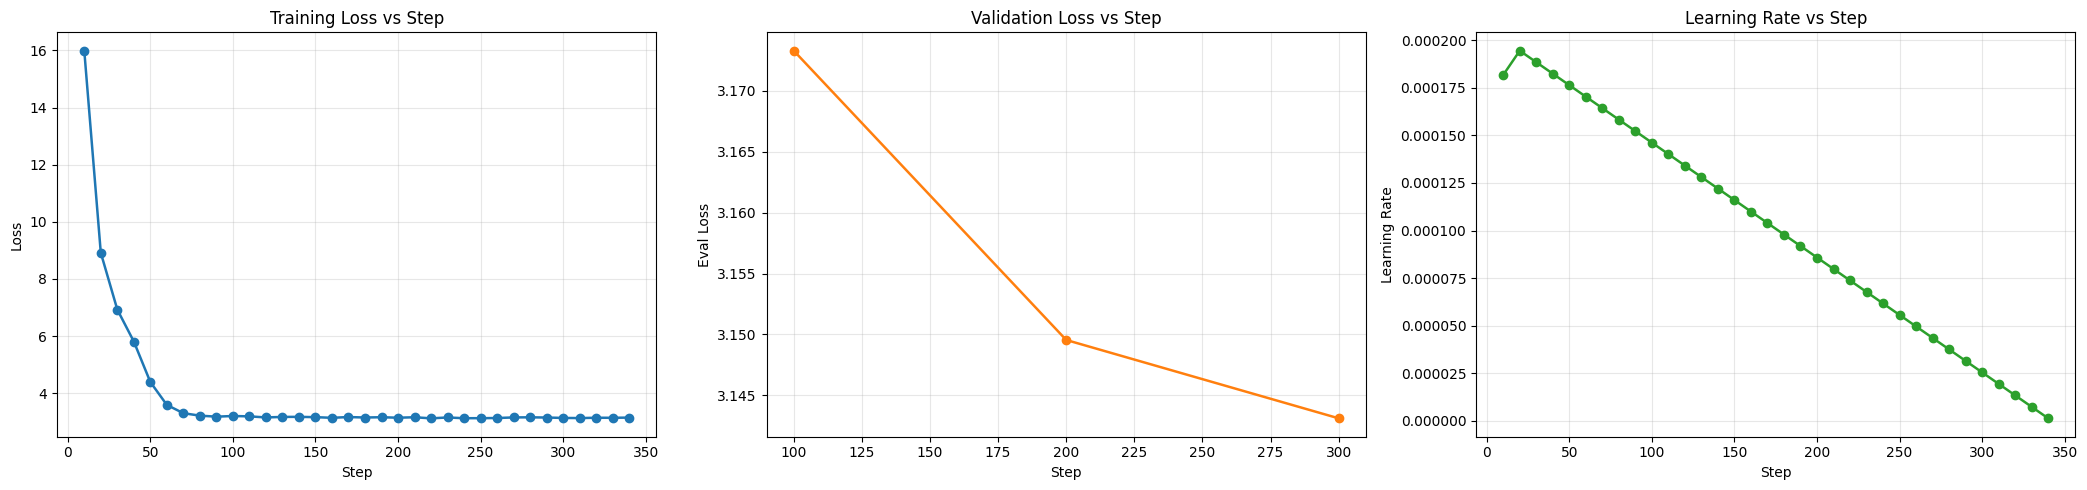

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
28,3.1503,0.803186,0.000044,1.578947,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,3.1550,0.814054,0.000037,1.637427,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,3.1468,0.743757,0.000031,1.695906,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,3.1333,0.866081,0.000025,1.754386,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,NaN,NaN,1.754386,300,3.143105,133.3842,1.14,1.14,NaN,NaN,NaN,NaN,NaN
33,3.1277,0.838266,0.000019,1.812865,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,3.1397,0.867402,0.000013,1.871345,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,3.1382,0.909115,0.000007,1.929825,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,3.1449,0.982624,0.000001,1.988304,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,2.000000,342,NaN,NaN,NaN,NaN,5984.8958,0.457,0.057,0.0,3.937193


In [32]:
# -------- Training diagnostics: loss/eval loss/learning rate charts --------
import pandas as pd
import matplotlib.pyplot as plt

if 'trainer' not in globals() or trainer is None:
    print('Trainer not found. Run the training cell first.')
else:
    log_history = getattr(trainer.state, 'log_history', None) or []
    if len(log_history) == 0:
        print('No trainer logs available to plot.')
    else:
        logs_df = pd.DataFrame(log_history)

        # Keep only rows that contain step info for consistent x-axis.
        logs_df = logs_df[logs_df.get('step').notna()].copy() if 'step' in logs_df.columns else logs_df.copy()
        if 'step' in logs_df.columns:
            logs_df['step'] = pd.to_numeric(logs_df['step'], errors='coerce')

        fig, axes = plt.subplots(1, 3, figsize=(21, 5))

        # 1) Train loss curve
        if 'loss' in logs_df.columns and 'step' in logs_df.columns:
            train_loss_df = logs_df[['step', 'loss']].dropna().sort_values('step')
            if len(train_loss_df) > 0:
                axes[0].plot(train_loss_df['step'], train_loss_df['loss'], marker='o', linewidth=1.8)
                axes[0].set_title('Training Loss vs Step')
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].grid(True, alpha=0.3)
            else:
                axes[0].text(0.5, 0.5, 'No training loss logs', ha='center', va='center')
                axes[0].set_title('Training Loss vs Step')
        else:
            axes[0].text(0.5, 0.5, 'No training loss logs', ha='center', va='center')
            axes[0].set_title('Training Loss vs Step')

        # 2) Eval loss curve
        if 'eval_loss' in logs_df.columns and 'step' in logs_df.columns:
            eval_loss_df = logs_df[['step', 'eval_loss']].dropna().sort_values('step')
            if len(eval_loss_df) > 0:
                axes[1].plot(eval_loss_df['step'], eval_loss_df['eval_loss'], marker='o', linewidth=1.8, color='tab:orange')
                axes[1].set_title('Validation Loss vs Step')
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Eval Loss')
                axes[1].grid(True, alpha=0.3)
            else:
                axes[1].text(0.5, 0.5, 'No eval loss logs', ha='center', va='center')
                axes[1].set_title('Validation Loss vs Step')
        else:
            axes[1].text(0.5, 0.5, 'No eval loss logs', ha='center', va='center')
            axes[1].set_title('Validation Loss vs Step')

        # 3) Learning-rate schedule
        if 'learning_rate' in logs_df.columns and 'step' in logs_df.columns:
            lr_df = logs_df[['step', 'learning_rate']].dropna().sort_values('step')
            if len(lr_df) > 0:
                axes[2].plot(lr_df['step'], lr_df['learning_rate'], marker='o', linewidth=1.8, color='tab:green')
                axes[2].set_title('Learning Rate vs Step')
                axes[2].set_xlabel('Step')
                axes[2].set_ylabel('Learning Rate')
                axes[2].grid(True, alpha=0.3)
            else:
                axes[2].text(0.5, 0.5, 'No learning-rate logs', ha='center', va='center')
                axes[2].set_title('Learning Rate vs Step')
        else:
            axes[2].text(0.5, 0.5, 'No learning-rate logs', ha='center', va='center')
            axes[2].set_title('Learning Rate vs Step')

        plt.tight_layout()
        plt.show()

        display(logs_df.tail(10))

In [33]:
# -------- Save adapters + training metadata --------
adapter_dir = Path(cfg.work_dir) / 'janus_hw_lora_adapter'
adapter_dir.mkdir(parents=True, exist_ok=True)

# Resolve trained model safely (wrapper -> inner multimodal model).
if 'trainer' not in globals() or trainer is None or getattr(trainer, 'model', None) is None:
    raise RuntimeError('Trainer/model not found. Run training before saving adapters.')

trained_model = trainer.model
inner_model = trained_model.mm_model if hasattr(trained_model, 'mm_model') else trained_model
language_model = getattr(inner_model, 'language_model', None)

if language_model is None or not hasattr(language_model, 'save_pretrained'):
    raise RuntimeError('Could not find a saveable language_model on the trained model.')

# Save LoRA adapter weights from the fine-tuned language model.
language_model.save_pretrained(adapter_dir)
processor.save_pretrained(adapter_dir)

meta = {
    'model_name': cfg.model_name,
    'train_size': int(len(train_df)),
    'val_size': int(len(val_df)),
    'prompt': PROMPT,
    'crop_top_ratio': cfg.crop_top_ratio,
    'crop_bottom_ratio': cfg.crop_bottom_ratio,
    'saved_component': type(language_model).__name__,
}

with open(adapter_dir / 'training_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved LoRA adapter to:', adapter_dir)
print('Saved component:', type(language_model).__name__)
print('Done.')

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(


Saved LoRA adapter to: /content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter
Saved component: PeftModelForCausalLM
Done.
